<a href="https://colab.research.google.com/github/annaBANNANA6/protein-interaction-network/blob/main/HINT_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing data**

*   `Uniprot_A` and `Uniprot_B`: standard identifiers for each protein in the pair
*   `Gene_A` and `Gene_B`
*   `pmid:method:quality:type`: each entry encodes PubMedID, experimental method, quality flag, interaction type together (seperated by colons)

--> if backed by both LC and HT, include both, separated by  '|' divider


*   `taxid`: NCBI taxonomy ID (confirms which orgnaism the interaction belongs to, human = 9606)
* `high_quality`: boolean confirming _hq values
* `in_pdb_source / PDB_IDs`: whether interaction has 3D structural evidence in Protein Data Bank, which structure ID if so





In [ ]:
import pandas as pd
data = pd.read_csv("https://hint.yulab.org/download-raw/2024-06/HomoSapiens_binary_hq.txt", sep = "\t")

print(f"shape: {data.shape}") # should be 163435, 9 columns
print(f"\ncolumns: {data.columns}")

data.head()

**data orientation**

Is `taxid` uniform (all human)?
Is `high_quality` all True?
How many rows have null for PDB_Ids (which interactions have structural evidence)?

In [ ]:
print(data['taxid'].unique()) # confirmed all human

print(data["high_quality"].unique()) # confirmed --> note to strip the space preceding this value

# data[data["PDB_IDs"].isna()]
print(f"# null rows for PDB_IDs: {(data["PDB_IDs"].isna()).sum()}")

so the results: all human, all high quality, and 149855/163435 of rows are null for PDB_IDs, meaning that most are missing 3D strutural info

---

**data cleaning**
note that due to nature of HINT's purpose to remove erroneous and low-quality entries, there is not much tabular data cleaning checks for this (and already checked taxid and quality).

network specific cleaning checks:
*   **Self-loops** (does any rows have Uniprot_A == Uniprot_B? this would biologically that a protein interacting with itself, which does happen but might not want to keep depending on research question
*   **duplicate or reciprocal edges** are there rows where A,B appears once and B,A appears as separate row? check since PPIs lack direction, so these are the same



In [ ]:
# self loop checks
self_loops = data[data["Uniprot_A"] == data["Uniprot_B"]]
print(f"Number of self loops / rows where A = B: {self_loops.shape[0]}")

# duplicate/reciprocal edges
# print(f"duplicates: {data.duplicated().sum()}")

# smaller in protein_1, larger in protein_2 (alphabetical comparison)
protein_1 = []
protein_2 = []

for index, row in data.iterrows(): # iterrow() - loop over df by row, each row is dict you index by column name
  a = row["Uniprot_A"]
  b = row["Uniprot_B"]

  if a < b:
    protein_1.append(a)
    protein_2.append(b)
  else:
    protein_1.append(b)
    protein_2.append(a)

# print(protein_1)
# print(protein_2)

# add sorted AB/BA columns back to DF and check duplicates
data["protein_1"] = protein_1
data["protein_2"] = protein_2
print(f"duplicates: {data.duplicated(subset = ["protein_1", "protein_2"]).sum()}")



In [ ]:
# alternative way to check duplicates using np methods
import numpy as np
data["protein_1"] = np.minimum(data["Uniprot_A"], data["Uniprot_B"])
data["protein_2"] = np.maximum(data["Uniprot_A"], data["Uniprot_B"])
print(f"duplicates: {data.duplicated(subset = ["protein_1", "protein_2"]).sum()}")

**results**: 0 duplicate rows, but 6034 self loops, so protein interacting with itself (**homodimeritzation** which is mechanism where some transcription factors and enzymes ONLY funciton when two copies of themselves bind together. even with bio significance, think about mathematical significance --> drop to avoid ambiguity of adding degree to protein,inflating clustering ocefficient (loops create triangles AAB)

---

In [ ]:
# dropping self loops for topological analysis
data.drop(self_loops.index)

**build network graph**: once edges become graph object, check for **isolated nodes** and **connected components**
*   **isolated node:** degree 0. consider that graph is being built from edge list itself so each node has at least on edge
*  **connected components**: component (cluster of nodes accessible from each other). usually get ONE big component with most proteins (small world effect) + long tail of smaller disconnected fragments (small clusters only interact w/ e/o

relevance: betwness centrality, shortest path length only WIHTIN compoment, so start analysis on giant component and note to do separately on smaller ones

**documentation**: https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html

https://pandas.pythonhumanities.com/04_02_graphing_networks_with_pandas.html



In [ ]:
# imports
import networkx as nx
import matplotlib.pyplot as plt

target proteins in HINT human (examples):
* TP53 (cellular tumor antigen p53) big hub protein for DNA repair and cell death

**Task:** Use networkx from pandas edgelist to create Graph. Choose target protein to create subgraph and visualize.

https://networkx.org/documentation/stable/reference/drawing.html

https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html


In [ ]:
# "networkx from pandas edgelist"" to create Graph
# edge_attr = True --> keeps experimental metadata onto edges
graph = nx.from_pandas_edgelist(data, source = "Uniprot_A", target = "Uniprot_B", edge_attr = True)

# subgraph for visualization
# ego_graph allows you to choose specific protein as "ego node"
target_protein = "P04637"  # uniprotID for TP53
subgraph = nx.ego_graph(graph, target_protein, radius = 1)

# NetworkX requires specific formatting (node1, node2, {attributes})
# graph.edges() returns pairs of connected nodes (Protein_A, Protein_B)
# adding edge.attr made NetworkX attaches to column values to each edge as a dictionary
print(subgraph.edges(data=True))

binary_edges = []
# loop to give tuples with start (u), end (v), dict of edge attributes (d)
for start_node, end_node, d in subgraph.edges(data=True):
  if d.get("evidence") == "binary":
    binary_edges.append((start_node, end_node)) #append clean list of start/end pairs w/o dictionary

complex_edges = []
for start_node, end_node, d in subgraph.edges(data=True):
  if d.get("evidence") == "co-complex":
    complex_edges.append((start_node, end_node))

# spring_layout returns X,Y coordinates (position nodes) calculated using FR algorithm
# k = distance bewteen nodes
position = nx.spring_layout(subgraph, k= 0.15, seed = 42)



In [21]:
# look at subgraph edge sample
first_edge = list(subgraph.edges(data=True))[0]
print("Your edge data looks like this:", first_edge)

Your edge data looks like this: ('P10398', 'P01106', {'Gene_A': 'MYC', 'Gene_B': 'ARAF', 'pmid:method:quality:type': '28205554:0055:HT:binary', 'taxid': 9606, 'high_quality': True, 'in_pdb_source': False, 'PDB_IDs': nan, 'protein_1': 'P01106', 'protein_2': 'P10398'})


In [ ]:
# __DISPLAY___!!!!!!!!!! yippeeeee
# nx.draw(subgraph)
# plt.show()

# draw nodes + specific node
nx.draw_networkx_nodes(subgraph, position, node_size = 300, node_color = "skyblue")
nx.draw_networkx_nodes(subgraph, position, nodelist = ["P04637"], node_size = 600, node_color = "blue")

# draw binary + complex edges
nx.draw_networkx_edges(subgraph, position, edgelist = binary_edges, edge_color = "red", style = "solid")
nx.draw_networkx_edges(subgraph, position, edgelist= complex_edges, edge_color = "green", style = "dashed")

nx.draw_networkx_edge_labels(subgraph, position)
nx.draw(subgraph)

wow how messy. improvements to the graph below to make it more visually understandable

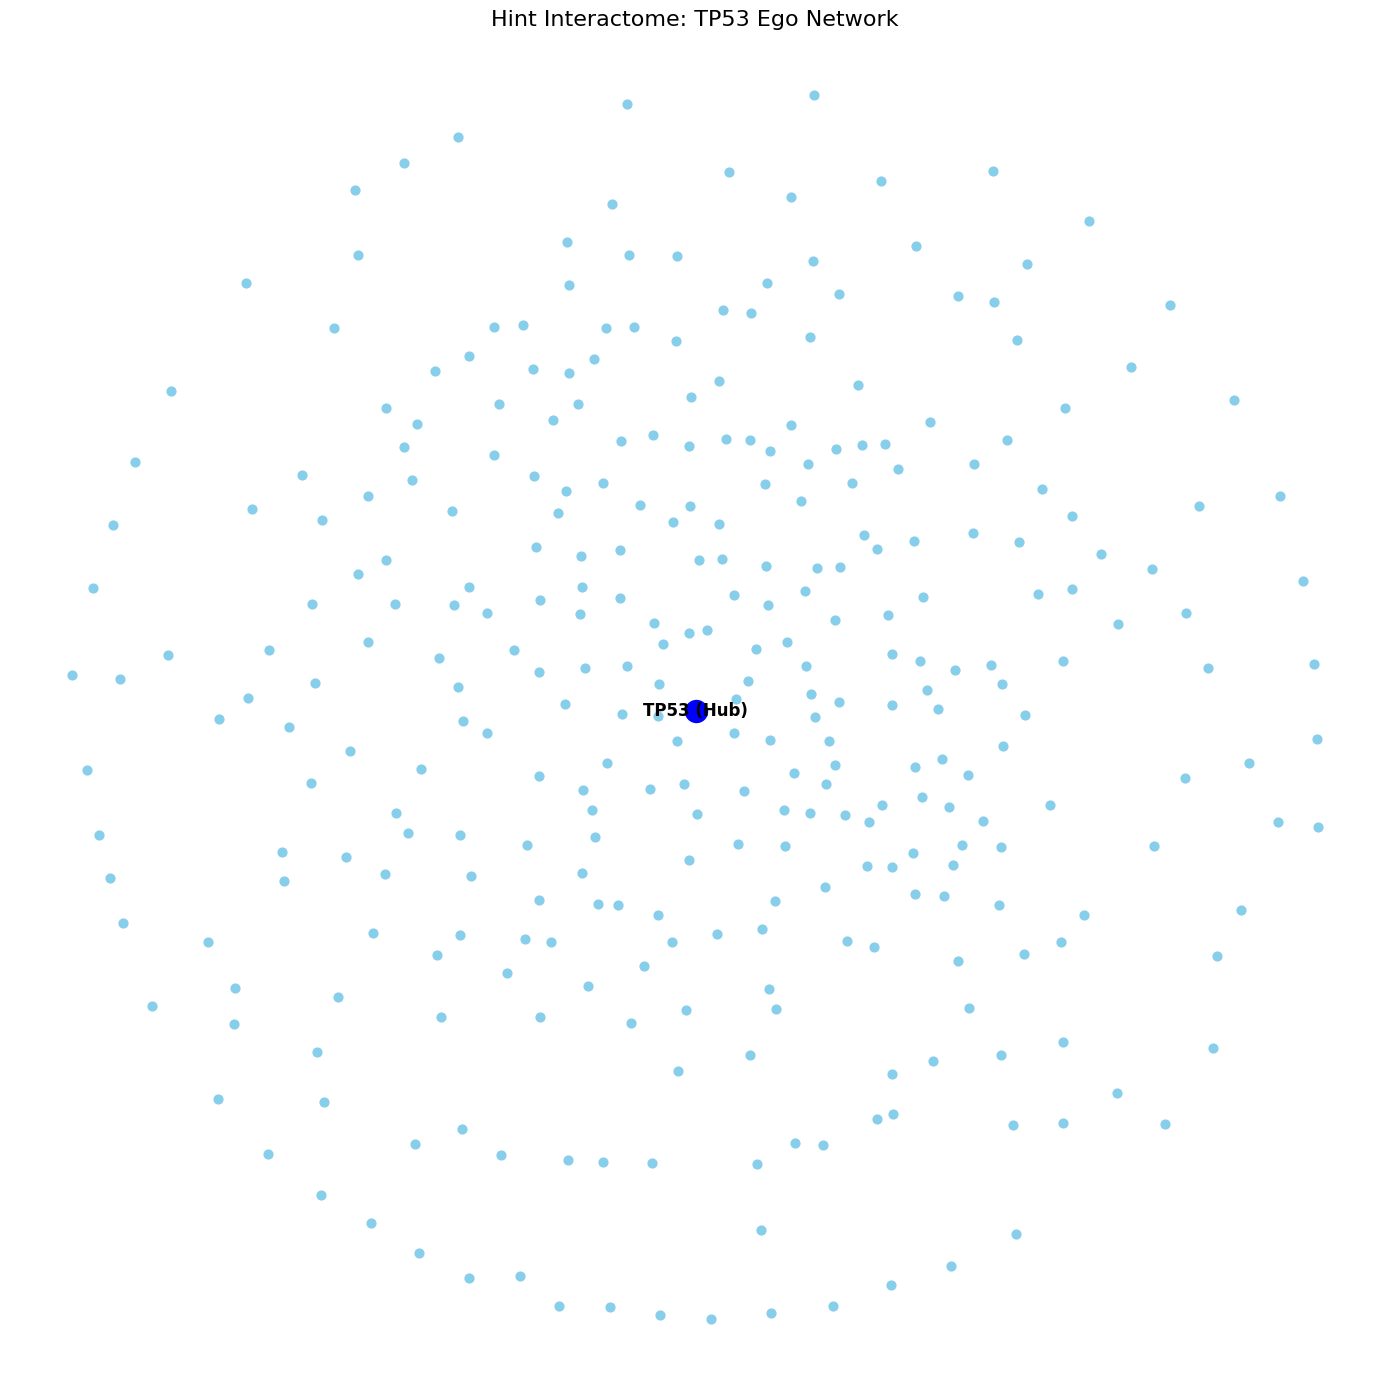

In [20]:
plt.figure(figsize= (14,14))

other_nodes = [node for node in subgraph.nodes() if node != "P04637"]
nx.draw_networkx_nodes(
    subgraph, position, nodelist = other_nodes, node_size =40, node_color = "skyblue"
)

nx.draw_networkx_nodes(subgraph, position, nodelist = ["P04637"], node_size = 250, node_color = "blue")

nx.draw_networkx_edges(subgraph, position, edgelist = binary_edges, edge_color = "red", style = "solid", alpha = 0.4, width = 1)
nx.draw_networkx_edges(subgraph, position, edgelist= complex_edges, edge_color = "green", style = "dashed", alpha = 0.2, width = 0.5)

# labels- this time only label the central hub/top 5 most important to avoid text explosion
labels = {"P04637": "TP53 (Hub)"}
nx.draw_networkx_labels(subgraph, position, labels=labels, font_size = 12, font_weight = "bold")

# clean edges
plt.title("Hint Interactome: TP53 Ego Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# network function related to connected components to extract them and to check if wholeg graph connected piece
# size of each component (combine components function with len() in loop)
# isolated nodes: "networks degree 0", G.degree()